# Detección de misoginia.

## Introducción

**Misoginia** :

    f. Aversión contra las mujeres.

**Machismo**

    m. Actitud de prepotencia de los varones respecto de las mujeres.

    m. Forma de discriminación sexista caracterizada por la prevalencia del varón. 

El discurso de odio hacia las mujeres representa una problemática social relevante. Debido a la relativia anonimidad de los entornos digitales, es en estos dónde el fenómeno se presenta con singular virulencia. Entre el espectro de las expresiones de odio se encuentran, desde las burlas, hasta explícitas incitaciones a la violencia. La detección del contenido violento y/o misógino representa un desafío de moderación considerable por el simple hecho del volúmen de datos que nos inundan todos los días. Identificar, clasificar y catalogar la violencia/misogínia es sin duda el primer paso para afrontar la problemática generada por la misma. 

Existe una amplia literatura al respecto del uso de sistemas de aprendizaje de máquina para identificar violencia en textos en inglés. Sin embargo, en el caso del español, existen ciertas limitantes que incrementan la dificultad del problema por lo que los esfuerzos que existen al respecto son limitados, comparados con el inglés. Un reto considerable es el hecho de que la naturaleza del lenguaje misógino se encuentra esparcida entre dos extremos, por un lado expresiones específicas y por otro, ímplicitas. Estas ultimas pueden observarse en formas que pueden ser irónicas o sarcásticas. Por si fuera poco, el significado en español algunas veces es relativo al pais o dialecto donde se origión la expresión. No es lo mismo el español latinoamericano argentino contra el colombiano o ibérico, por poner un ejemplo. 

El presente trabajo tiene como fin proponer un sistema de clasificación automática basado en algoritmos de aprendizaje de máquina para identificar discurso de odio hacia las mujeres. Uno de los reqquerimientos es generar un sistema que balancee la precisión con la exhaustividad. Una moderación estricta, si no es precisa, puede generar censura injustificada, un sistema de clasificación muy conservador puede permitir la circulación de discurso violento. El objetivo deseado es producir un sistema que optimize la precisión sin sacrificar la capacidad de detección.

En ese contexto, este reporte de investigación aborda la construcción y evaluación de sistemas de clasificación binaria de misoginia para textos cortos en español. Se discutirán a detalle técnicas de procesamiento de lenguaje natural para el diseño de los mismos, usando diversas técnicas de limpieza, preprocesamiento y análisis con el objetivo final de determinar un sistema que tenga el mejor desempeño. Este ultimo siendo definido, nuevamente, a partir de un sistema que optimize la precisión sin sacrificar la exhaustividad. 


## Base de Datos. 

Uno de los retos más significativos para emprender esta tarea es la recopilación de una base de datos que abarque las sutilezas, variantes y diversas connotaciones que caracterizan al idioma español. Como se mencionó anteriormente, el argot, el sarcasmo, las expresiones coloquiales típicas de dialectos regionales así como las variantes inherentes a un lenguaje tan extendido representan algunas de las dificultades. Afortunadamente, ya han existido esfuerzos, sobre todo de investigadores españoles, para consolidar observaciones que permitan entrenar sistemas de clasificación automática, entre los que destacan:

* La base de datos de AMI-Ibereval. 

* La base de datos de Misocorpus 2020. 

* Corpus RNN. 

La base de datos sobre la que se realizó el presente trabajo se construyó a partir del MisoCorpus2020 y del Corpus RNN.

### Origen de los datos. 

#### MisoCorpus2020

El misocorpus consiste de 7682 *tweets* (mensajes cortos de texto pertenecientes a la red social X) que fueron etiquetados como misóginos/no misóginos por un panel de expertos. Vale la pena mencionar que el consenso al respecto no siempre es unánime, lo cual demuestra la complejidad de la tarea de clasificación, así como confirma los comentarios al respecto de su dificultad mencionados en la sección anterior. 

El corpus esta dividido en 3 subconjuntos:

* VARW. El cual recopila tweets misóginos dirigidos hacia mujeres específicas de la esfera pública. (Celebridades de múltiples ámbitos).
* SELA. El cual recopila tweets misóginos/no misóginos de diversas regiones de latinoamérica y españa.
* DDDS. El cual recopila tweets misóginos/no misóginos que demuestren específicamente descrédito, dominancia, abuso sexual o estereotipos.
 
Dada la naturaleza de estos subconjuntos, se espera que el sistema de clasificación a desarrollar pueda analizar la misogínia a partir de, respectivamente, un contexto social, variaciones de dialectos regionales y abusos específicos.

#### Corpus RNN 

El corpusRNN fue desarrollado con un enfoque particular hacia el español latinoamericano, a partir de modelos de lenguaje y generadores de datos. 

Este corpus se constituye de:

* Una compilación de canciones misóginas seleccionadas manualmente.
* Refranes y expresiones populares latinoamericanas.
* Texto sintético generado mediante modelos de redes neuronales recurrentes. (RNN)
* La recopilación de textos aleatorios en español mediante un rastreador web que fue inicializado con palabras misóginas clave.

La diversidad de estas fuentes permite que el corpus incorpore expresiones explícitas e implícitas de la misoginia, que abarquen aspectos importantes como expresiones de lenguaje irónico/sarcástico o condicionadas a cierto contexto.

#### Consolidación

Juntos, ambos corpus incorporan datos que representan las siguientes ventajas:

* contexto social.
* variaciones del lenguaje de acuerdo a región.
* Variantes específicas de misogínia.
* contexto cultural.

Sin embargo, vale la pena mencionar que la base datos consolidada también tiene ciertas desventajas.

* Posible sesgo en la recolección. 
* Subjetividad en la anotación.


La misoginia, lamentablemente, se puede presentar tanto explícita como implícitamente, a veces incluso disfrazada de expresiones neutras y/o humorísticas. Es por ello que se determinó que un corpus nutrido de diversas fuentes, aún con las limitantes mencionadas anteriormente, constituye un buen punto de partida para un sistema de clasificación automática. 


## Análisis Exploratorio de la Base de Datos. 

### Descripción general de la base. 

La base de datos consiste de 11,114 textos cortos en español. La mayoría de ellos **tweets** de la red social X, todos etiquetados como violento/no violento con respecto a la misoginia. 

Es importante recalcar que la cantidad de textos violentos sobrepasa la de los no violentos casi en una proporción de 3 a 1. Específicamente, hay 8102 observaciones violentas vs 3012 observaciones no violentas. Este desbalance no puede pasar desapercibido ya que debe ser considerado a la hora de diseñar y evaluar los sistemas de clasificación, así como también en la calibración de los umbrales del sistema de producción.

### Longitud de los textos. 

En la figura 1 se observa la distribución de la cantidad de palabras por cada texto en la base de datos. 


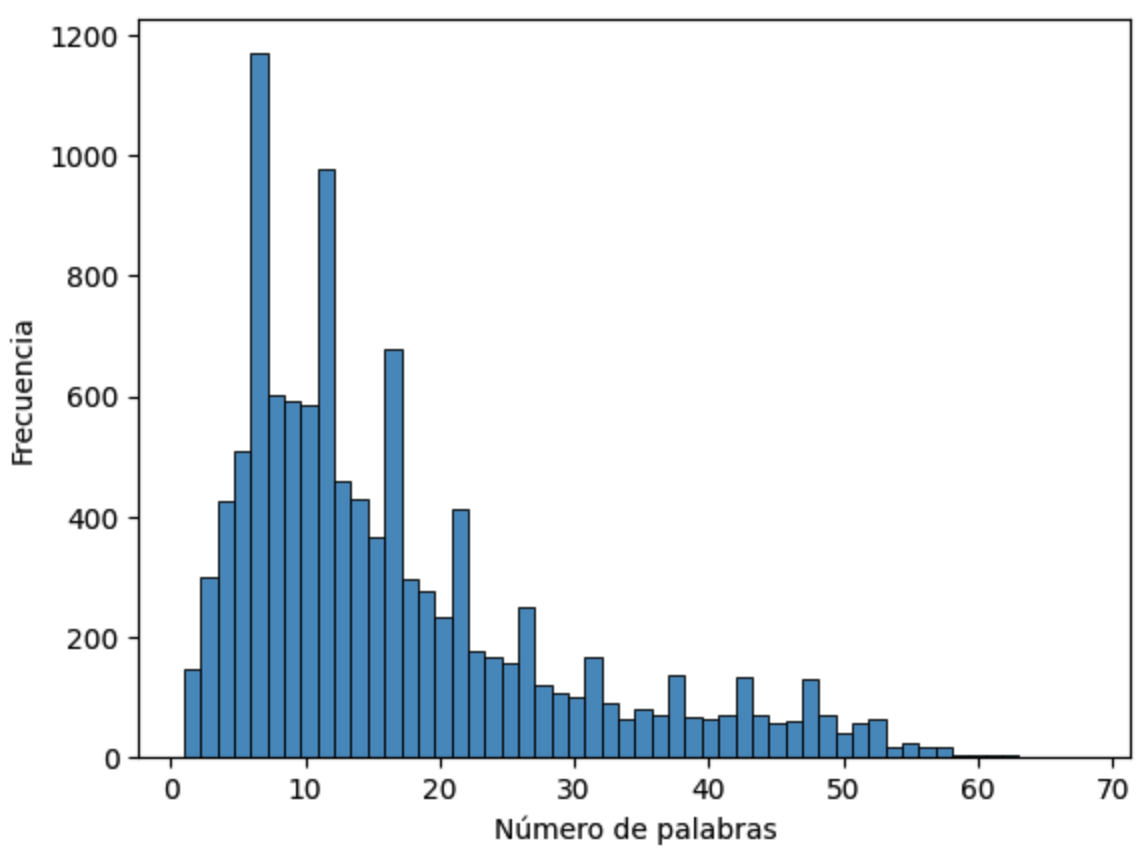

En la figura 2 se observa que la longitud de los textos es prácticamente irrelevante para clasificarlos como misógino/no misógino, ya que presentan distribuciones muy similares. 

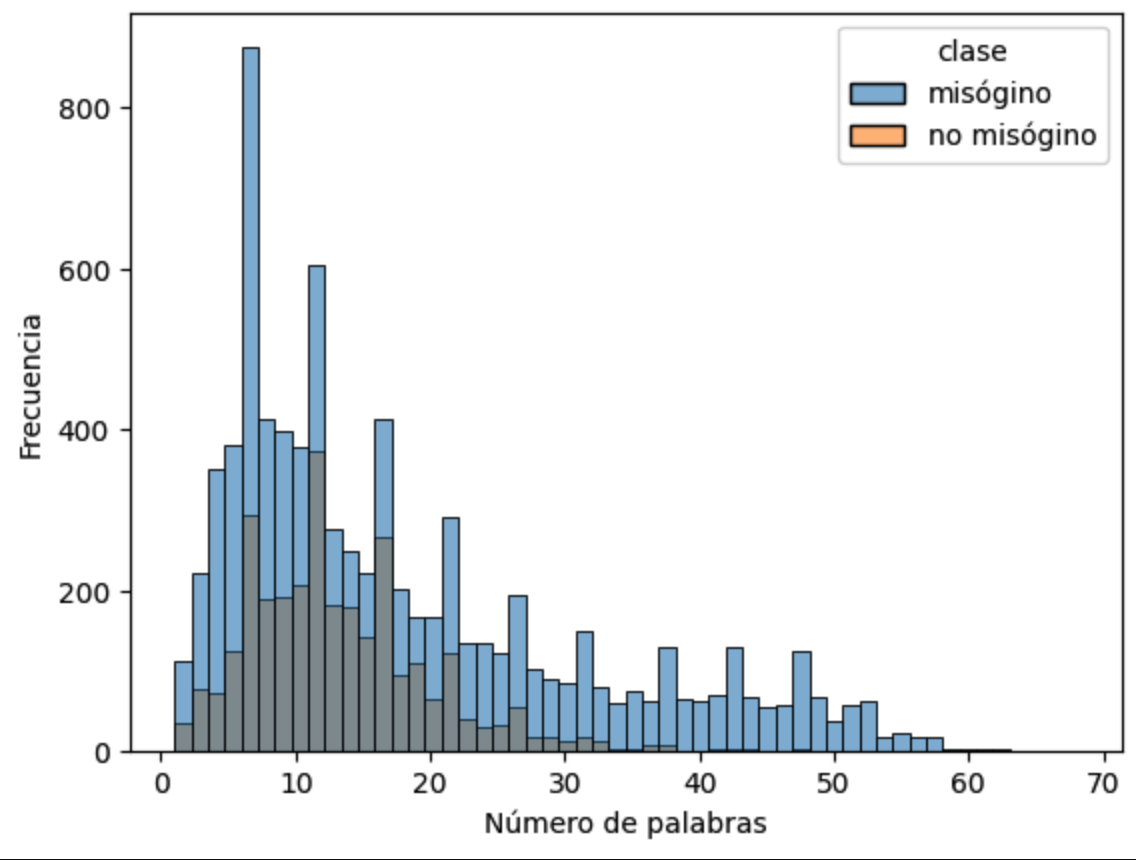

### Análisis léxico.

Se realizó un análisis de frecuencia de palabras por clase violenta/no violenta. Como puede verse en las figuras 3 y 4, los textos violentos cuentan con una alta frecuencia de términos en español explícitamente agresivos/degradantes contra la mujer. Por otro lado, los textos no violentos presentan una terminología mucho más neutral, ambigua. Esta característica de la base de datos sugiere que hay una varianza/diferencia léxica clara (palabras muy distintas entre clases) que modelos de clasificación pueden potencialmente detectar. No obstante, vale la pena mencionar que también existe vocabulario en común (la palabra **mujer** es un claro ejemplo) que sugieren una varianza semántica. Por decirlo simplemente, las palabras encierran un patrón de diferenciamiento, efectivamente, pero también el contexto.




En la figura 3 se observan las palabras mas frecuentes en los textos misóginos.

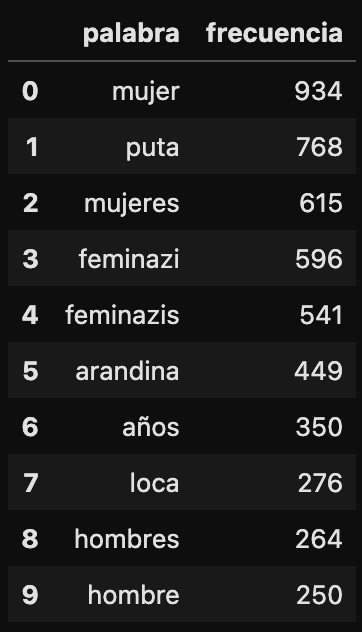

En la figura 4 se observan las pablabras más frecuentes en los textos no misóginos. 

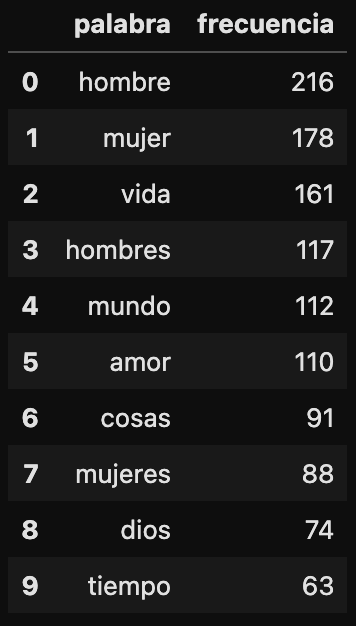

#### Solapamiento léxico entre clases.

Cuantificar el solapamiento de palabras entre clases puede darnos una medida explícita de lo mencionado anteriormente. Para estos casos se suele utilizar el coeficiente de Jaccard. 

Dados dos conjuntos de palabras A y B, el coeficiente de Jaccard se calcula como el cociente del numero de elementos de la intersección de los conjuntos A y B, y el número de elementos de la unión de A y B. 

$$
J(A, B) = \frac{|A \cap B|}{|A \cup B|}
$$


Por ejemplo, si A y B tienen las mismas palabras, el coeficiente será 1, y si no tienen ninguna palabra en común, el coeficiente será 0.



Vocabulario violento: 14729
Vocabulario no violento: 5631
Palabras compartidas: 3202

El coeficiente de similitud de Jaccard entre los textos violentos y no violentos es de .18 


Existe un conjunto significativo de palabras distintivas asociadas a los textos violentos, por lo que muchos términos por si mismos pueden ayudar a identificar
contenido violento/ no violento. Sin embargo también existen 3202 palabras que se solapan, lo cual aunado a un coeficiente de Jaccard de .18,
este valor sugiere que existe un conjunto considerable de palabras compartidas entre ambos tipos de textos lo cual puede
sugerir que los sistemas de clasificación que tomen en cuenta diferencias léxicas y semánticas pueden tener un mejor desempeñó que aquellos que solo tomen
en cuenta las diferentes palabras entre los textos. 


### Palabras discriminativas. 


A continuación, para identificar términos representativos de cada tipo de texto, se calculó el logaritmo del cociente de frecuencias entre palabras de ambos textos. 

$$
\text{log-odds}(w) = \log_2 \left( \frac{f_v(w) + 1}{f_{nv}(w) + 1} \right)
$$

donde: 

$$
f_v(w) = \text{frecuencia de la palabra } w \text{ en la clase violenta}
$$

$$
f_{nv}(w) = \text{frecuencia de la palabra } w \text{ en la clase no violenta}
$$

el +1 corresponde a una constante de suavizamiento que evita la división entre 0 para palabras que no existen en los textos no violentos. 

Si comparamos el cociente, sabemos que un valor > 1 corresponde a palabras que aparecen mas en la clase violenta, y < 1 palabras que aparecen más en la case no violenta. 
Sin embargo, el valor del cociente no es muy comparable visualmente entre palabras en términos de magnitudes, por lo que una vez que aplicamos el logaritmo base 2, obtenemos simetría. 

Ejemplo:

Tomemos dos palabras, A y B. 

 A aparece en 99 textos violentos, y en 9 textos no violentos. 
 B aparecen en 99 textos no violentos y en 9 textos violentos.


Para una palabra A: 100/10 = 10

Para una palabra B: 10/100 = .1

Si aplicamos el logaritmo base 2:

Para una palabra A: log2(10) = + 3.32

Para una palabra B: log2(.1) = - 3.32

Por lo tanto , para valores > 0 la palabra w aparece más en la clase violenta. En correspondencia, para valores < 0 la palabra w aparece más en la clase no violenta. Esta métrica nos permite comparar palabras entre sí y detectar aquellas que son representativas de cada clase. 


En la figura 5 se puede apreciar que los textos violentos, como se mencionó anteriormente, tienen como términos dominantes palabrás violentas y explícitas, contrario a los términos de la clase no misógina. Nuevamente se sospecha que las señales léxicas son la mejor forma de diferenciación, sin dejar de lado, en menor forma, las señales semánticas asociadas muchas veces a contenido implícito. 

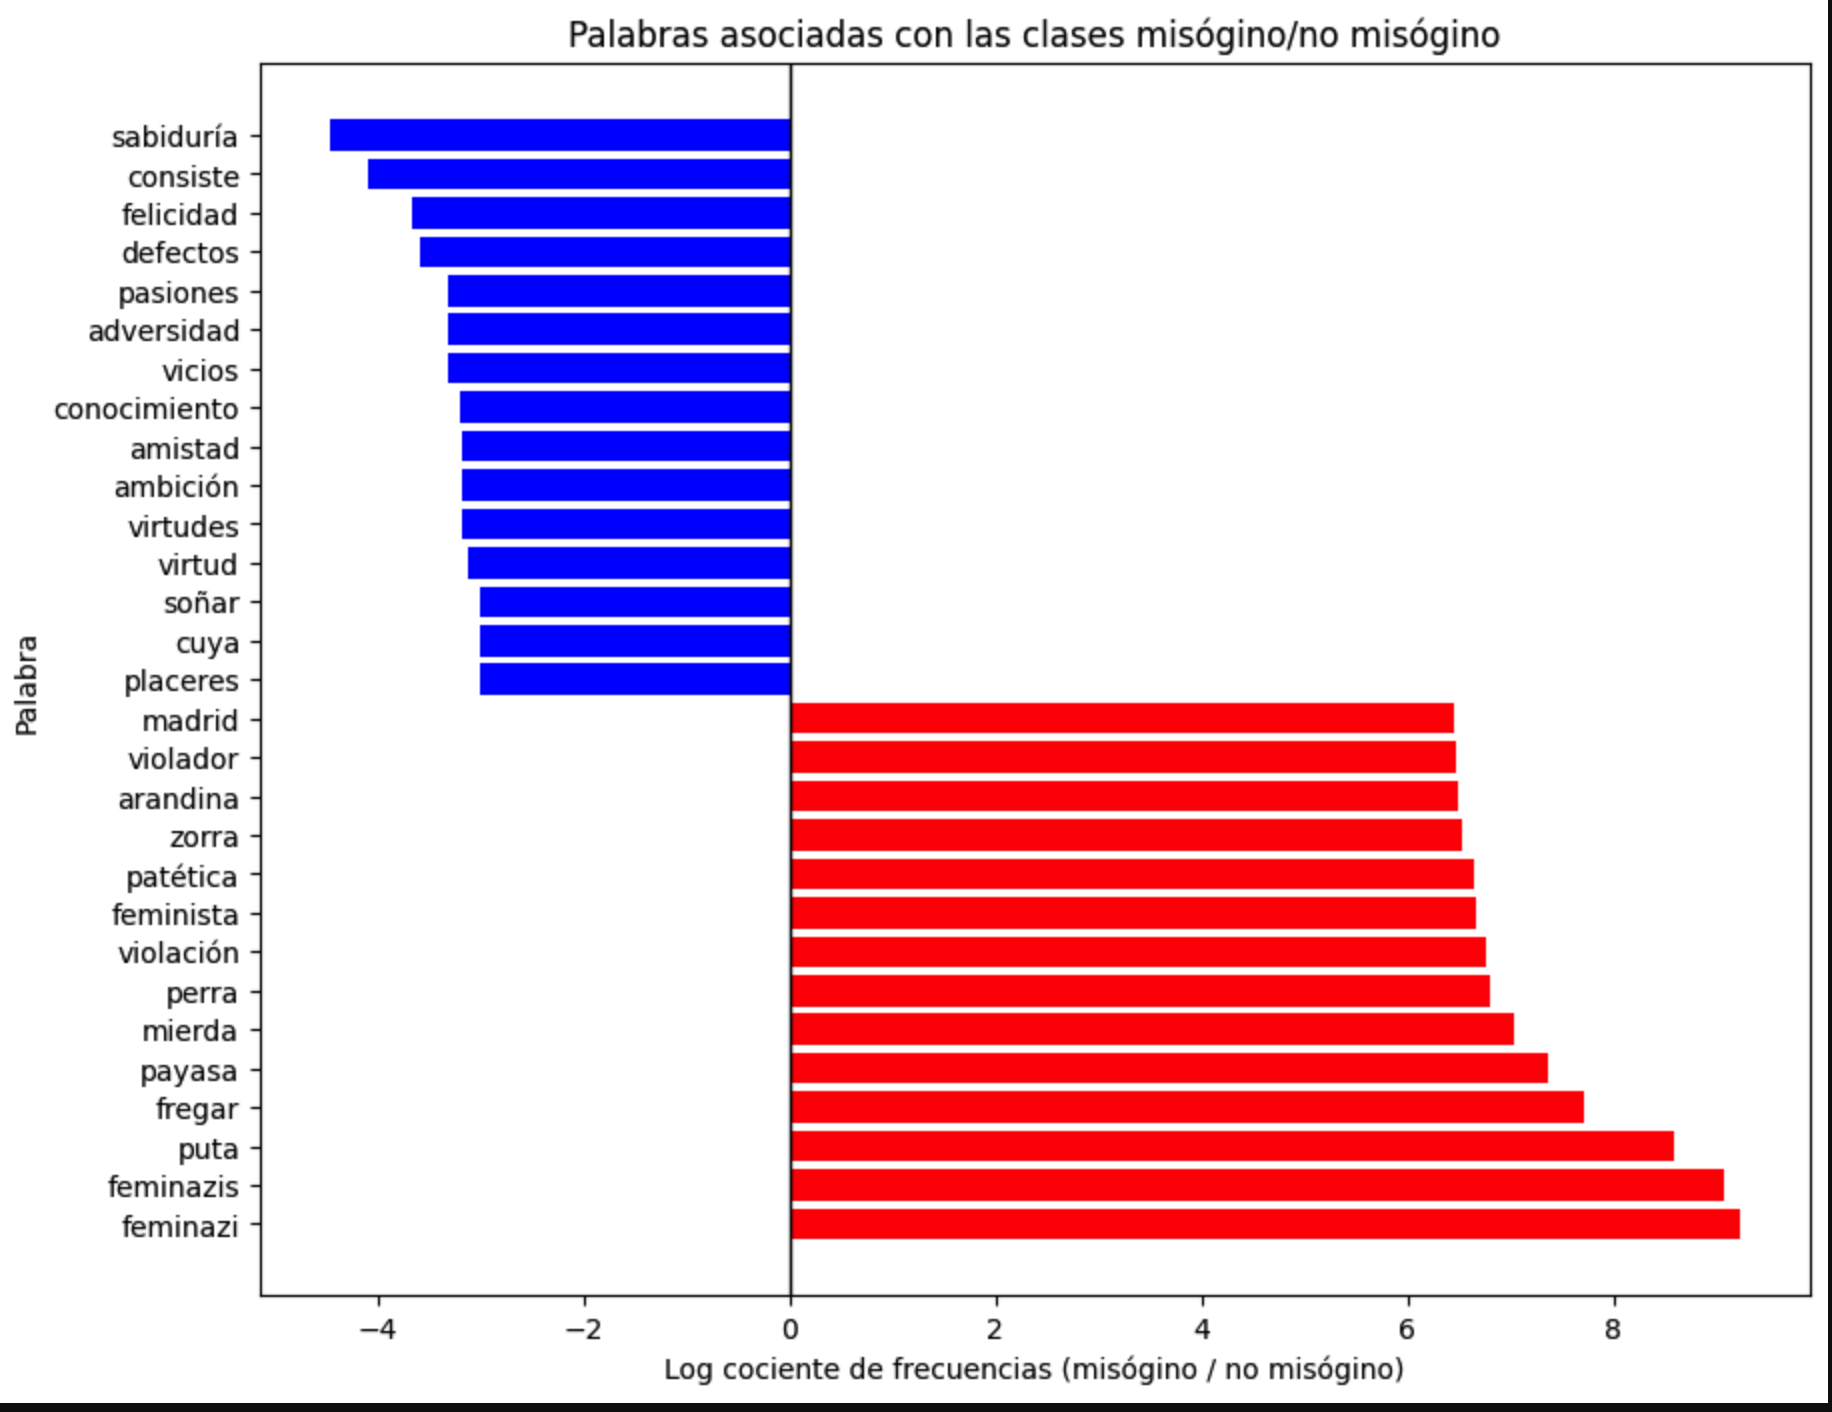

### Análisis de n-gramas. 

Con respecto al contenido semántico de los textos se realizó un análisis de bigramas y trigramas para detectar la frecuencia de patrones compuestos, así como la posible evidencia de señal semántica. 

Como se observa en las figuras 6 y 7, la presencia de palabras explícitas no necesariamente indica violencia, el contexto es necesario para determinarlo, y este se puede inferir a partir de las combinaciones de palabras. Esto señala que un sistema de clasificación precisio necesita capturar la señal relacionada a estas combinaciones, no puede reducirse al significado y/o presencia de palabras individuales. 



Figura 6. Bigramas más frecuentes.
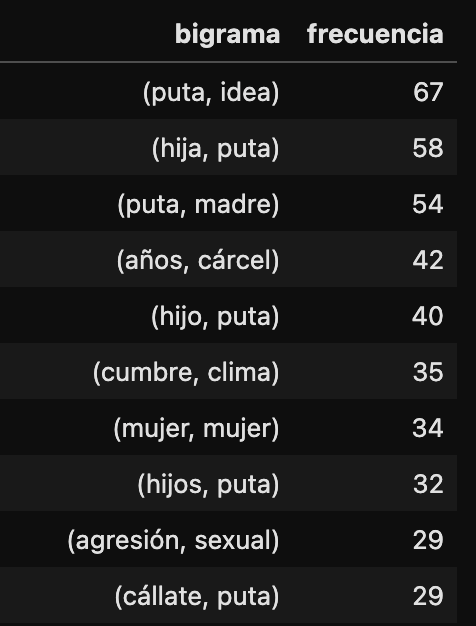


Figura 7. Trigramas más frecuentes.
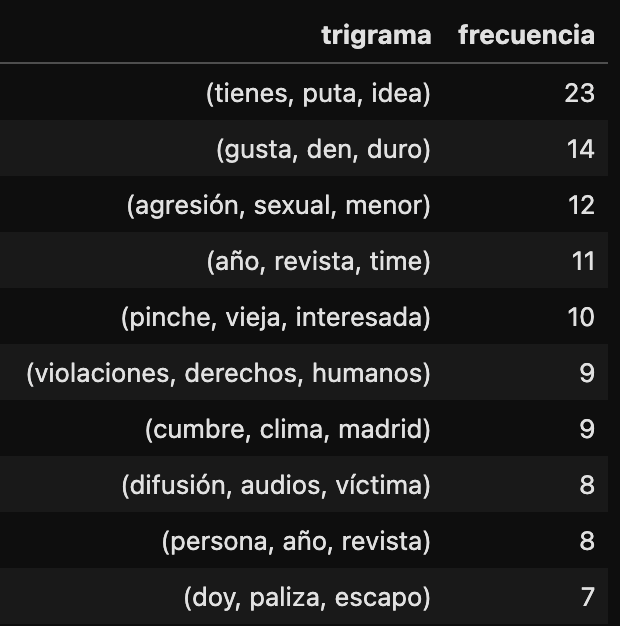

### Representaciones visuales.

A continuación se presentan las nubes de palabras asociadas a cada clase. Estas representaciones permiten observar la predominancia de ciertos términos en cada clase, asi como en la base de datos. 


El análisis exploratorio claramente demuestra señales léxicas importantes en la base de datos, específicamente en la clase misógina. Sin embargo, también hay que recalcar que existe un importante conjunto de vocabulario compartido entre clases, lo que justifica la necesidad de incorporar preprocesamiento que capture también la señal semántica, contextual y no sólo la que corresponde a vocabulario. El fenómeno como bien lo sugiere la introducción, abarca contenido explícito así como implícito, por lo que es importante capturar la señal de ambos. 

Figura 8. Nube de palabras, textos misóginos
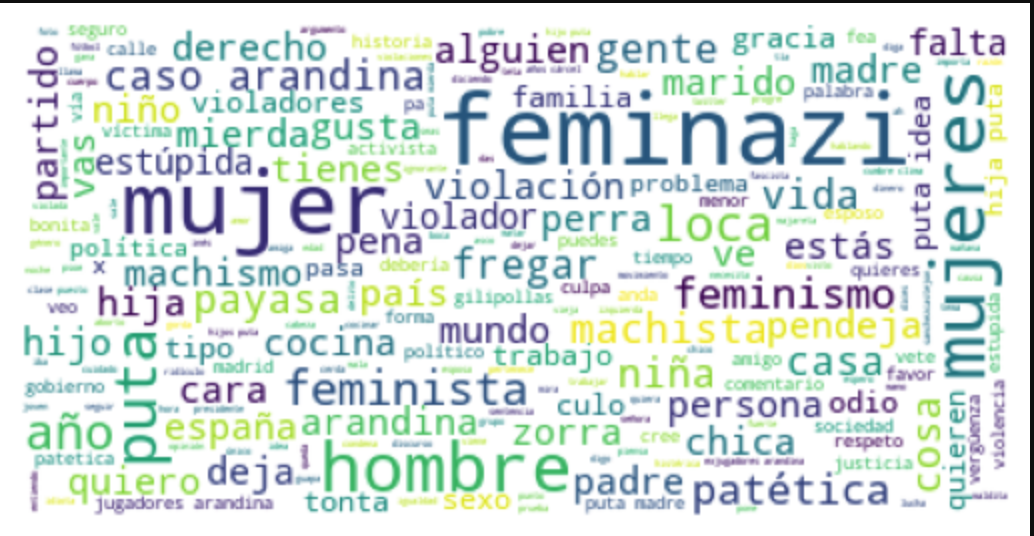

Figura 9. Nube de palabras, textos no misóginos.
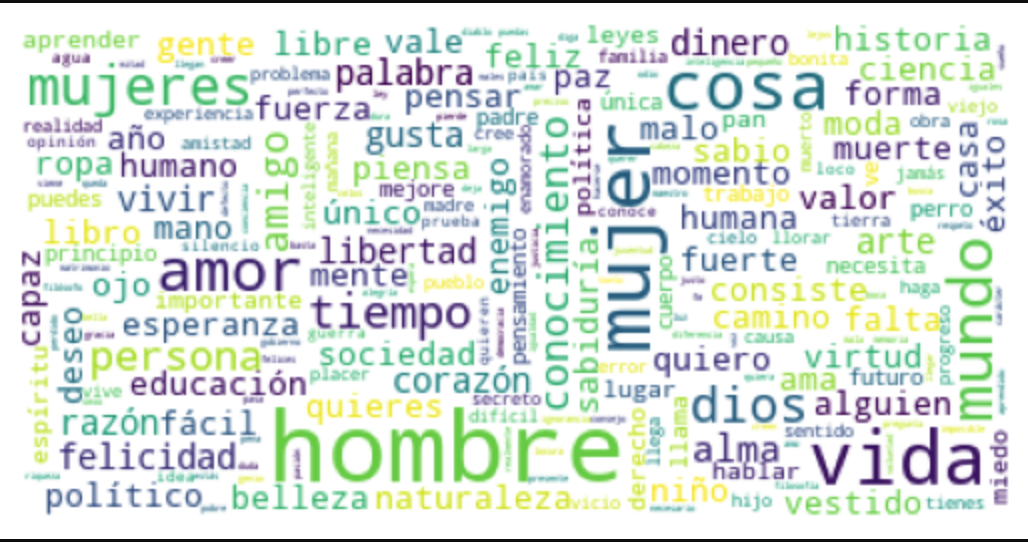

## Preprocesamiento.

El preprocesamiento del texto es un paso crucial para diseñar un sistema de clasificación de lenguaje natural y comprende dos fases:

1. Limpieza: Es necesario reducir el ruido presente en los textos, manteniendo el contenido léxico-semántico relevante y facilitar la extracción de patrones discriminativos.
2. Transformación: Es necesario transformar los textos a representaciones numéricas adecuadas para los algoritmos de aprendizaje autómático.

Ya que en su mayoría, la base de datos consiste en en textos cortos provenientes de entornos digitales, el proceso de limpieza fue diseñado de forma conservadora, evitando ediciones u omisiones que pudieran eliminar información contextual. 

### Limpieza. 

Se llevaron a cabo las siguientes transformaciones:

* Eliminación de urls.:

  Las urls son efectivamente textos que en muy raras ocasiones aportan información relevante de la clasificación.

* Conversión a minúsculas:

  Para simplificar el entrenamiento de los sistemas, esta conversión simplifica la administración de tokens, donde Mujer, mujer o MUJER, representan la misma palabra y no tres distintas.

* Corrección de abreviaciones comunes:

  Es una practica común de los hispanohablantes el abreviar ciertas trancisiones comúnes. q -> que d -> de, grax -> gracias, etc. La normalización de los mismos consolidará la señal léxica. 

* Homologación de espacio antes y después de cada texto:

* Eliminación de textos de una sola palabra. 

* Eliminación de textos que solo contenían una url/imagen.

* Eliminación de emojis. Considerando que su contribución semántica es limitada y requiere un procesamiento especial, se eliminaron del vocabulario.

Las decisiones que se tomaron en materia de limpieza tienen como fin reducir la dispersión del vocabulario, contando con representaciones consistentes de palabras/entidades, que de ser tratadas como palabras distintas, agregarían varianza innecesaria a los modelos a entrenar. 

### Métodos de representación de textos 

Para entrenar un sistema de clasificación de textos, es preciso transformarlos a representaciones numéricas significativas. 

Entre los métodos más comunes destacan: 

* Bolsas de palabras (Bag of words)

* *TFIDF*

* *Embeddings*

El primero tiene limitaciones significativas al respecto de separar la señal del ruido, el segundo funciona bastante bien para detectar señal léxica y el último detecta tanto señal léxica como semántica, como se verá más adelante, sólo se optaron por los últimos dos dadas las limitantes del primero.  

#### Bolsas de palabras. 

Dado un documento de texto, esta transformación consiste en un vector con las frecuencias de aparición de cada término en el documento.

Ejemplo
Observación A "Nunca Nunca confies en una mujer" -> [Nunca -> 2, confies -> 1, en -> 1, una -> 1, mujer -> 1].

Este enfoque es seriamente limitado por que no considera el poder discriminativo de los términos, su relevancia global en un corpus de documentos, así como la crelación semántica/ contexto entre los términos.

#### *TFIDF*

Consiste en generar vectores de alta dimensionalidad que reflejen la importancia de cada palabra en el corpus.
Nótese que el resultado es proporcional a la frecuencia de la palabra en un sólo texto e inversamente proporcional a 
la presencia del término en todos los documentos. 

Es importante señalar que este método no captura relaciones entre términos. Por que la señal semántica derivada de ciertas combinaciones o mensajes implícitos le es invisible. 


$$
\text{tf-idf}(t, d) = \text{tf}(t, d) \cdot \left[ \log \left( \frac{N + 1}{\text{df}(t) + 1} \right) + 1 \right]
$$

$$
\text{tf}(t, d) = \text{frecuencia del término } t \text{ en el documento } d
$$

$$
\text{df}(t) = \text{número de documentos que contienen el término } t
$$

$$
N = \text{número total de documentos}
$$

Ejemplo
Observación A "las mujeres deben ser calladas" 
Observación A "Los derechos de las mujeres han mejorado"
Observación C "prefiero hombres para este trabajo"

Tablas.

| Documento | Palabra   | tf | df(t) | idf (relativo) | tf-idf (relativo) |
|----------|----------|----|------|----------------|-------------------|
| A        | mujeres  | 1  | 2    | bajo           | bajo              |
| A        | deben    | 1  | 1    | alto           | alto              |
| A        | calladas | 1  | 1    | alto           | alto              |
| B        | mujeres  | 1  | 2    | bajo           | bajo              |
| B        | derechos | 1  | 1    | alto           | alto              |
| C        | hombres  | 1  | 1    | alto           | alto              |
| C        | trabajo  | 1  | 1    | alto           | alto              |

Comentario.

"Mujeres" tiene poco poder discriminativo por que aparece en dos textos.
"Calladas" y "deben" destacan en su tf-idf por que solo aparecen una vez.
las palabras de la observación C, que es misoginia implícita tienen tambien un tfidf alto
pero ninguna es explícitamente ofensiva por sí sola. Esto es una de las limitaciones de tfidf, El contexto. 

Notas:

La métrica de idf suele ser suavizada para evitar que sea 0. 
Frecuentemente, se aplica una normalización de tipo l2 al vector para hacerlo de norma 1 y hacerlo comparable a otros documentos, independientemente de su longitud.

#### *Embeddings* 

Los *embeddings* representan palabras o textos como vectores densos en un espacio continuo. Contrario a tf-idf y bolsa de palabras, estos vectores si capturan relaciones semánticas entre los términos. Dicho de otra forma, permiten modelar el contexto. Esto probablemente sea útil al momento de detectar misoginia implícita, donde el contexto la determina, en vez de palabras individuales. 

Cada documento/texto, se representa como un vector en un espacio multidimensional. La idea fundamental de los embeddings como transformación es que documentos con significado/contexto similar sean representados por vectores cercanos/similares entre sí. 

En este caso, la definición de cercanía/similitud entre dos documentos se da  por la fórmula de la similitud coseno, la cual se define como: 

$$
\text{sim}(A, B) = \frac{\sum_{i=1}^{n} A_i B_i}{\sqrt{\sum_{i=1}^{n} A_i^2} \cdot \sqrt{\sum_{i=1}^{n} B_i^2}}
$$

Donde:

- $A$ y $B$ representan los vectores de embeddings asociados a dos palabras o textos.

- $A \cdot B$ es el producto punto entre los vectores $A$ y $B$.

- $\|A\|$ y $\|B\|$ corresponden a la norma (magnitud) de los vectores $A$ y $B$, respectivamente.


Valores cercanos a 1 implican alta similitud semántica, mientas que valores cercanos a 0 indican baja relación. 


Existen dos grandes categorías de embeddings :

Embeddings estáticos (e.g., FastText):
asignan un mismo vector a cada palabra independientemente del contexto.

Embeddings contextuales (e.g., MiniLM, LaBSE):
generan representaciones que dependen del contexto en el que aparece la palabra o el texto completo.

En este trabajo, el uso de embeddings contextuales permitió capturar formas implícitas de misoginia que no pueden ser identificadas únicamente mediante señales léxicas.

Validación empírica de embeddings usando mini lm. 

Similitudes coseno

Se calcularon los embeddings preentrenados para las siguientes palabras y posteriormente
se calcularon las similitudes coseno entre los vectores de las mismas.

Similitudes coseno.

| Par de palabras        | Similitud coseno |
|----------------------|------------------|
| mujer - mujeres      | 0.878            |
| mujer - femenina     | 0.968            |
| inferior - débil     | 0.674            |
| insulto - desprecio  | 0.760            |
| violencia - agresión | 0.857            |

Se observa que términos semánticamente relacionados presentan alta similitud, por ejemplo:

mujer – mujeres (0.878)

mujer – femenina (0.968)

Asimismo, términos asociados a atributos negativos y lenguaje ofensivo también se agrupan de forma coherente:

inferior – débil (0.674)

insulto – desprecio (0.760)

violencia – agresión (0.857)

Estos resultados evidencian que los embeddings organizan las representaciones en función del significado, capturando relaciones semánticas consistentes más allá de coincidencias léxicas.


### Consideraciones sobre *stop words*

Las stop words son palabras de alta frecuencia que, en muchas tareas de procesamiento de lenguaje natural, suelen aportar poca relevancia discriminativa. Frecuentemente consisten de artículos, preposiciones y/o conjunciones como: *el*, *la*, *que*, *en*, etc.

Como se verá más adelante, sólo se utilizaron los métodos TFIDF, así como los embeddings por lo que se tomo la decisión de no eliminar las stop words. Asimismo, debido a que la mayoría de las observaciones son textos cortos, estas pueden llegar a formar parte del contexto del mensaje. 

No es necesario preocuparse acerca de agregar varianza innecesaria al entrenamiento de los algoritmos. En el caso de tf-idf, dada la naturaleza de esa transformación, las stop words tienen su relevancia severamente penalizada. En el caso de los embeddings, las stop-words aportan contexto semántico por lo que es preciso mantenerlas. 

### Consideraciones sobre lematización

La lematización transforma palabras a su forma canónica, preservando su significado, con el objetivo de reducir la variabilidad léxica en el procesamiento de texto

No se aplicó lematización, dado que:

En modelos basados en embeddings, las variaciones morfológicas son capturadas de manera natural.

En TF-IDF, la reducción puede eliminar señales relevantes o introducir ambigüedad en ciertos contextos.

## Modelado

### Herramientas

Se utilizó la librería *scikit-learn* para la implementación de los modelos, debido a que proporciona algoritmos de aprendizaje de máquina robustos y estandarizados, así como herramientas integradas para validación cruzada y optimización de hiperparámetros. Su uso facilita la reproducibilidad de los experimentos y la consistencia en la evaluación de los modelos.

### División de los datos. 

La base de datos fue dividida en dos conjuntos, entrenamiento y prueba, en una proporción del 70%-30% respectivamente. Esto con el fin de evaluar el desempeño de los modelos de clasificación, así como su capacidad de generalizar a datos sobre los cuales no fueron entrenados. 

La base cuenta con más observaciones misóginas vs no misóginas. En términos de representatividad, lo más deseable es que la proporción de de los datos misóginos-no-misóginos represente la distribución real. Esta última es, lamentablemente, desconocida, ya que no hay evidencia que sugiera una distribución/proporción específica.

Si la proporción de los datos misóginos/no-misóginos es aproximadamente 3:1 tanto en el conjunto de entrenamiento como en el de prueba, se corre el riesgo de introducir un sesgo hacia la clase mayoritaria (textos misóginos), lo cual puede afectar su capacidad para generalizar correctamente, especialmente en la detección de la clase minoritaria. Para mitigar este efecto, se adoptaron estrategias diferenciadas para cada subconjunto.

En el conjunto de entrenamiento se decidió conservar la distribución original de las clases. Esta decisión tiene como objetivo evitar la pérdida de información relevante, especialmente en la clase mayoritaria, que contiene una mayor variedad de patrones. Técnicas de sobremuestreo no fueron consideradas debido que implicarían agregar redundancia artificial. Por lo tanto, se decidió ponderar de forma distinta los errores de clasificación, mediante la modificación de la funcion de pérdida de forma inversamente proporcional a la frecuencia de cada clase. Dicho de otra forma, los errores de clasificación cometidos sobre la clase minoritaria serían penalizados en mayor forma que aquellos sobre la clase mayoritaria. Con esta medida, se corrige el sesgo de los datos hacia la clase misógina, sin perder información relevante.

Un ejemplo con entropía cruzada. (*log loss*), nótese:

$$
\mathcal{L} = - \frac{1}{N} \sum_{i=1}^{N} w_{y_i}
\left[
y_i \log(\hat{y}_i) + (1 - y_i)\log(1 - \hat{y}_i)
\right]
$$

$$
w_{y_i} = w_c \quad \text{con } c = y_i
$$

$$
w_c = \frac{N}{n_c}
$$

Donde:

- $N$ representa el número total de observaciones en el conjunto de entrenamiento.

- $i$ indexa cada una de las observaciones, de modo que $i = 1, 2, \dots, N$.

- $y_i \in \{0,1\}$ es la etiqueta real de la observación $i$, donde $1$ representa la clase misógina y $0$ la clase no misógina.

- $\hat{y}_i$ es la probabilidad estimada por el modelo de que la observación $i$ pertenezca a la clase positiva.

- $\mathcal{L}$ es la función de pérdida (*loss function*), la cual mide qué tan bien se ajusta el modelo a los datos.

- $w_{y_i}$ es el peso asignado a la observación $i$, determinado por la clase a la que pertenece.

- $w_c$ es el peso asociado a la clase $c$, definido en función del número de observaciones de dicha clase.

- $n_c$ representa el número de observaciones pertenecientes a la clase $c$.
  

Por otro lado, el conjunto de prueba fue balanceado. Esta decisión permite evaluar el desempeño de los modelos de manera equitativa entre clases, evitando que métricas agregadas se vean influenciadas por la distribución original de la base datos.

De manera complementaria, en los apéndices se incluye la evaluación sobre el conjunto de prueba desbalanceado, cuyos resultados fueron consistentes con la evaluación principal

### Validación e Hiperparámetros

Para el entrenamiento de los modelos y la selección de hiperparámetros, se decidió usar validación cruzada (*Cross Validation*), en combinación con búsqueda exhaustiva hiperparámetros (*GridSearch*)

#### Validación Cruzada.

Para entrenar un modelo, comúnmente se divide la base de entrenamiento en dos: entrenamiento y validación. Por ello el desempeño del modelo esta ligado a la partición elegida. En contraparte la validación cruzada consiste en dividir los datos de entrenamiento en múltiples particiones (*folds*), entrenando el modelo en un subconjunto de ellas y validandolo en la particion restante, repitiendo el proceso hasta que todas las particiones hayan sido utilizadas como conjunto de validación. Esto permite obtener una estimación más robusta y estable del rendimiento promedio del modelo y ayuda a prevenir el sobreajuste.

#### Búsqueda Exhaustiva. 

La búsqueda exhaustiva es una tecnica de optimización de hiperparámetros de modelos. Consiste en evaluar todas las combinaciones posibles dentro de un conjunto predefinido de valores. Para cada combinación, el modelo a entrenar es entrenado y evaluado, junto con validación cruzada, con respecto a la métrica de desempeño a optimizar. PAra efcetos de nuestro objetivo, esta es la precisión.

En vez de seleccionar hiperparámetros de forma arbitraria, este mecanismo nos permite explorar las distintas combinaciones del espacio hiperparametral para optimizar los modelos. 

En el ejemplo que se muestra a continuación, se definió una malla de hiperparámetros para el ajuste de un modelo de regresión logística. 

En particular, se consideraron cuatro valores para el parámetro de regularización `C`, dos tipos de penalización `l`.

En total, la rejilla tiene 4×2=8 combinaciones posibles. Para cada una de ellas, se entrena un modelo utilizando validación cruzada y se evalúa con base en la métrica de precisión.


```python
param_grid_logreg = {
    'logreg__C': [0.01, 0.1, 1, 10],
    'logreg__penalty': ['l1', 'l2']
}
```

### Métrica a Optimizar.

Bajo el supuesto que el sistema de clasificación de misogínia a entrenar puede ser utilizado como un sistema de moderación, se decidió optimizar el ajuste de los modelos con respecto a la precisión de detección sobre la clase misógina. 

En un sistema de clasificación binario existen dos tipos de errores, falso positivo y falso negativo. En un sistema de moderación/ detección de contenido violento/misogino se considera más grave un falso positivo (clasificar texto como misógino cuando en realidad no lo es), ya que conlleva una posibilidad de penalización, veto o censura. Dicho de otra forma, se prioriza el ajuste de un modelo conservador, que si afirma detectar contenido misógino, lo haga con un alto grado de confianza.

En menor medida, se consideró también el recall como métrica complementaria, con el fin de armonizar, una alta precisión con una (en menor medida) alta capacidad de detección.

$$
\text{Precision} = \frac{TP}{TP + FP} \tag{1}
$$

$$
\text{Recall} = \frac{TP}{TP + FN} \tag{2}
$$

Una vez que se obtengan modelos candidatos a ser puestos en producción, se revisitará este trade-off entre precision y recall para optimizar los umbrales de decisión.

### Modelos.

#### Representaciones de texto.

Se evaluaron distintas representaciones del texto con el objetivo de analizar su impacto en el desempeño de los modelos. 

En particular, se utilizaron representaciones basadas en conteo de palabras (*Bag of Words*) mediante *CountVectorizer*, así como representaciones TF-IDF, que ponderan la importancia de los términos en función de su frecuencia relativa en el corpus.

Adicionalmente, se evaluaron representaciones basadas en embeddings, tanto estáticos (FastText) como contextuales (MiniLM y LaBSE), las cuales permiten capturar relaciones semánticas más complejas entre palabras.

Estas representaciones fueron previamente descritas en la sección de preprocesamiento, por lo que en esta sección se enfatiza su uso dentro del proceso de modelado.

#### Modelos a Entrenar

Se evaluaron distintos modelos de clasificación supervisada con el objetivo de comparar su desempeño bajo las diferentes representaciones del texto.

* Naive Bayes 
* Regresión logística
* Máquina de soporte vectorial.
* Bosques aleatorios. 

#### Naive Bayes

Como modelo base, se utilizó un clasificador Naive Bayes en su variante multinomial. Este modelo se basa en el teorema de Bayes, bajo la suposición de independencia condicional entre las características.

$$
P(y \mid x) \propto P(y)\prod_{j=1}^{d} P(x_j \mid y)
$$

En el caso multinomial, donde se consideran frecuencias de palabras:

$$
P(x \mid y) \propto \prod_{j=1}^{d} P(w_j \mid y)^{x_j}
$$

donde $x_j$ representa la frecuencia del término $w_j$ en el documento.

Este modelo permite establecer una línea base basada en señales léxicas.



#### Regresión logística

La regresión logística es un modelo lineal que estima la probabilidad de pertenencia a una clase mediante la función sigmoide aplicada a una combinación lineal de las características:

$$
\hat{y} = \sigma(w^T x + b) = \frac{1}{1 + e^{-(w^T x + b)}}
$$

El modelo se entrena minimizando la función de pérdida logarítmica (entropía cruzada):

$$
\mathcal{L} = - \frac{1}{N} \sum_{i=1}^{N} 
\left[
y_i \log(\hat{y}_i) + (1 - y_i)\log(1 - \hat{y}_i)
\right]
$$

Este modelo es particularmente adecuado para datos de alta dimensionalidad y permite aprender pesos discriminativos para cada característica.



#### Máquinas de soporte vectorial (SVC)

Las máquinas de soporte vectorial buscan encontrar un hiperplano que maximice la separación entre clases en el espacio de características:

$$
f(x) = w^T x + b
$$

El modelo se entrena resolviendo el siguiente problema de optimización:

$$
\min_{w,b} \frac{1}{2} ||w||^2 + C \sum_{i=1}^{N} \xi_i
$$

sujeto a:

$$
y_i (w^T x_i + b) \geq 1 - \xi_i, \quad \xi_i \geq 0
$$

donde $C$ controla el balance entre maximizar el margen y penalizar errores de clasificación.

En este trabajo se emplearon principalmente versiones lineales de SVC, dado su buen desempeño en espacios de alta dimensionalidad.



#### Random Forest

Random Forest es un modelo basado en conjuntos de árboles de decisión. Cada árbol realiza una predicción y el resultado final se obtiene mediante votación mayoritaria:

$$
\hat{y} = \text{mode} \{ h_1(x), h_2(x), \dots, h_T(x) \}
$$

donde $h_t(x)$ representa la predicción del árbol $t$.

Este modelo permite capturar relaciones no lineales entre variables, aunque su desempeño en representaciones de texto de alta dimensionalidad suele ser inferior al de modelos lineales.

## Evaluación y Resultados. 

### 6.1 Resultados generales. 

Para cada tipo de modelo, y mediante la búsqueda exhaustiva con validación cruzada sobre el conjunto de entrenamiento, se seleccionaron los hiperparámetros que tuvieron el mejor desempeño en términos de precisión para detectar misoginia. La siguiente tabla presenta las configuraciones óptimas. 

Posteriormente se evaluó el desempeño de los modelos seleccionados sobre el conjunto de prueba. La siguiente tabla presenta los resultados en términos de precisión, recall y f1-score. 

Es importante señalar que se observa una mejora en el desempeño de los modelos en la medida en que las representaciones de texto se vuelven más complejas, pasando de enfoques basados en frecuencias hasta representaciones semánticas*embeddings*. La naturaleza de esta mejora es consistente con la literatura, quqe afirma que las representaciones qque consideran el contexto y la semántica tienen mejores resultados, contrario a representaciones solamente basadas en frecuencias.

### Modelo base: Naive Bayes.

Como modelo base, se seleccionó el clasificador *Naive Bayes*, empleando representaciones basadas en conteos de palabras. 

Como se puede observar en la tabla, si bien tiene un recall competitivo (.89) su precisión (.82) es comparativamente la peor de todos los modelos, por lo que incurrirá en falsos positivos con mayor propensión que los demás modelos.

Esto se debe a la naturaleza del modelo ya que asume independencia condicional entre las características/palabras del texto, por lo que podemos decir que sobre-reacciona a palabras frecuentes en la clase misogina, pero es incapaz de hacer una discriminación más fina, que tome en cuenta contexto y/o las relaciones entre palabras.

### Comparación en cuanto representación del texto.

#### Modelos con representaciones *tf-idf*

El uso de representaciones *tf-idf* mejora la precisión de los modelos considerablemente. Tanto el modelo de regresión logística como bosques aleatorios obtuvieron una precisión de .89 y .90, respectivamente. Sin embargo, el recall empeoró bastante, por lo que si bien estos modelos son precisos (pocos falsos positivos), su capacidad detección es menor (bastantes falsos negativos).

A diferencia de la bolsa de palabras, la representación tf-idf toma en cuenta tanto la frecuencia asi como la relevancia de los términos en un corpus. Las palabras redundantes, reciben, debido a ello un menor peso en el modelo. No obstante, tf-idf no captura información contextual-semántica como sí lo hacen las representaciones basadas en embeddings. 

La mejora en precisión sugiere que los modelos tienen la capacidad de detectar la señal léxica asociada a la presencia o no de ciertos términos basados en su importancia relativa. No obstante, el recall es sumamente inferior al obtenido en sus variantes con embeddings, lo que sugiere la presencia de una señal semántica, contextual, que también permite diferenciar entre clases. Dado ese nivel de recall, la capacidad de detección es insuficiente, ya que deja de detectar muchos textos misóginos. 

#### Modelos basados en *embeddings*.

Los mejores modelos fueron aquellos que utilizaron *embeddings* como representaciones de texto. En particular aquellos que usan las representaciones *labse*.

Consistentemente, los modelos con embeddings presentaron una mejoría en recall respecto a los modelos qque usaron tf-idf, manteniendo o incluso mejorando los niveles de precisión. A partir de esto se puede inferir que las representaciones semánticas permiten detectar relaciones entre palabras, que para enfoques puramente léxicos, son invisibles.

Entre los diversos embeddings que se probaron, minilm y fast text presentan métricas cercanas pero ligeramente inferiores a labse. Esto puede explicarse por la capacidad de estas ultimas para capturar relaciones en múltipes variantes del español. 

### Comparación en cuanto a la arquitectura de los modelos. 

En cuanto a las familias de modelos, se observa una clara superioridad de los modelos lineales frente a aquellos basados en árboles o kernels no lineales. Este resultado se confirma no solo en el desempeño sobre el conjunto de prueba, sino también en la consistencia entre la precisión obtenida sobre el conjunto de entrenamiento (precision_training) y la observada en el conjunto de prueba.

#### Regresión Logística

Los modelos de regresión logística, particularmente con representaciones basadas en embeddings, presentan un desempeño bastante consistente con valores de precisión y recall mayores al 90%. Estos modelos rara vez se equivocan para etiquetar textos misóginos, y su capacidad de detección también es bastante alta. Adicionalmente, la diferencia entre la precisión obtenida sobre el conjunto de entrenamiento ( 0.97) y la observada en el conjunto de prueba (≈ 0.90) es moderada, lo cual indica una buena capacidad de generalización.

Cabe resaltar que en regresión logistica con representaciones tf-idf, los hiperparámetros óptimos fueron la regularización l1 (lasso), asi como un parámetro de regularización C = 1, que se considera moderado. Esto se puede explicar con la naturaleza del espacio generado por las representaciones tf-idf el cual puede considerar disperso (*sparse*), y donde el modelo se ajusta mejor eliminando términos irrelevantes del texto. Sin embargo, como se vio con la evaluación sobre el conjunto de prueba, la capacidad de detección y generalización de este modelo es limitada.

Por otra parte, en los modelos con embeddings, llama la atención que para los distintos tipos de embeddings (fast, minilm y labse), los parámetros optimos sugieren una regularización alta que le permita al modelo generalizar. Asimismo, el tipo óptimo de regularización es ridge l2, que suaviza, no selecciona, el aporte de los textos al modelo. Esto se puede explicar por que el espacio de embeddings, comparado al de tfidf es denso y estructurado, por lo que no es conveniente eliminar/seleccionar características.


#### Máquinas de soporte vectorial 

Los resultados de las máquinas de soporte vectorial dependen principalmente de la representación del texto.

En los modelos con TF-IDF, los parámetros óptimos corresponden a un valor elevado de C=100 (baja regularización) junto con un kernel no lineal RBF. Aunque estos modelos alcanzan valores elevados de precisión sobre el conjunto de entrenamiento (≈ 0.95), su desempeño en el conjunto de prueba es considerablemente inferior (≈ 0.83 en precisión y bajo recall). El uso de kernels no lineales en espacios de alta dimensionalidad, como los generados por TF-IDF, introduce complejidad innecesaria sin mejorar el desempeño. Dado que estos espacios tienden a ser aproximadamente linealmente separables, esta combinación favorece el sobreajuste, lo que implica que el modelo está capturando patrones específicos del conjunto de entrenamiento que no son generalizables a nuevos datos.


En contraste, en los modelos con embeddings se observa que los valores óptimos corresponden a C = .1, lo que implica una mayor regularización, junto con el uso de un kernel lineal. En estos modelos, la diferencia entre la precisión del conjunto de entrenamiento (≈ 0.95) y el conjunto de prueba (≈ 0.88–0.89) es menor, lo cual indica una mejor capacidad de generalización que los modelos tf-idf. Esto sugiere que el problema es aproximadamente linealmente separable en el espacio de embeddings, y que modelos lineales son suficientes para capturarlo de manera efectiva. En particular, ese modelo con representaciones labse obtuvo un desempeño bastante competitivo comparable al modelo de regresión logística con *embeddings* labse.


#### Bosques Aleatorios

Los bosques aleatorios, si bien tuvieron una alta precisión, tienen un recall muy inferior a sus contrapartes lineales (.74), lo que indica que aunque preciso, este modelo es muy conservador y tiene una reducida capacidad de detección. Este comportamiento se puede explicar por la naturaleza del modelo, ya que construye reglas locales sobre subconjuntos de los datos, lo cual puede limitar la capacidad de generalización en espacios de alta dimensionalidad como lo son los problemas de texto. El desempeño es insuficiente comparado con los modelos lineales que operan sobre todo el espacio de características. 

Si bien la diferencia entre la precisión en el conjunto de entrenamiento y en el conjunto de prueba es comparable a la de otros modelos, el bajo recall y f1-score evidencia una capacidad de generalización inferior a los modelos lineales.

### Selección de modelos candidatos.

Los modelos que tuvieron el mejor desempeño, esto es el mejor balance entre una precisión y recall altos (En ese orden), fueron 
la regresión logística con embeddings Labse y la máquina de soporte vectorial con embeddings labse. 

Tabla.

## Calibración.

En un sistema de clasificación binaria, además de la etiqueta de la clasificación, es importante analizar la confiabilidad de las probabilidades asociadas a cada predicción. Un modelo se considera confiable/bien calibrado cuando sus probabilidades predichas reflejan adecuadamente la frecuencia real de la clase positiva; es decir, entre todos los casos con probabilidad p, aproximadamente una fracción p pertenece realmente a dicha clase.

Específicamente para un detector de misoginia, la calibración es importante ya que las decisiones finales (misógino/no misógino) dependen de la selección de un umbral sobre las probabilidades. Debido a ello, probabilidades mal calibradas pueden conducir a decisiones subóptimas, incluso si el modelo presenta un buen desempeño en términos de clasificación.

### Evaluación de caliubración.

La calibración de los modelos candidatos fue evaluada sobre el conjunto de prueba mediante dos métodos, curvas de calibración y el *Brier score*.

#### Curvas de calibración. 


Las curvas de calibración comparan las probabilidades predichas con la frecuencia relativa observada de la clase misógina en distintos intervalos de probabilidad, donde un modelo hipotéticamente perfectamente calibrado se visualizaría como una linea diagonal. 

Los resultados muestran que el modelo de regresión logística con embeddings labSE presenta una curva de calibración muy cercana a la diagonal., lo cual indica uqe las probabilidades del modelo son consistentes con las proporciones de la clase misógina. Este hecho sugiere que el modelo esta bien calibrado. 

A diferencia de la regresión logística, que estima probabilidades por diseño, las máquinas de soporte vectorial generan puntajes (scores) de decisión. Para obtener probabilidades, se utiliza un proceso de calibración conocido como escalamiento de Platt, donde se ajusta una función sigmoide sobre dichos puntajes.

Sin embargo, la curva de calibración del modelo SVC presenta una desviación considerable respecto a la diagonal, lo cual indica que sus probabilidades son menos confiables en comparación con las de regresión logística.

#### Brier Score.

Como medida cuantitativa para analizar la confiabilidad de las predicciones de ambos modelos, se utilizó el *Brier score*.

El Brier Score se define como el error cuadratico medio entre las probabilidades de un modelo y las etiquetas reales. Mientras menor sea el score, el modelo se considera bien calibrado y sus probabilidades confiables. 

El modelo de regresión logística tuvo un brier score de .063 vs .0889 del modelo de la máqquina de soporte vectorial, lo cual confirma que la regresión logística produce probabilidades más confiables.

tabla

#### Selección del modelo de producción. 

En conjunto, los resultados indican que, si bien ambos modelos presentan un buen desempeño en términos de clasificación, la regresión logística ofrece probabilidades significativamente mejor calibradas. Esto es consistente tanto con la forma de las curvas de calibración como con los valores del Brier score, por lo tanto, este es el modelo final para el sistema de clasificación.

## Ajuste de umbral de decisión.

En un modelo de clasificación binaria, la decisión final se obtiene comparando la probabilidad predicha con un umbral, comúnmente fijado en 0.5. Sin embargo, este valor no necesariamente es óptimo, especialmente en contextos donde los costos asociados a los distintos tipos de error no son equivalentes.

En este trabajo, el objetivo principal es maximizar la precisión en la detección de contenido misógino, minimizando la ocurrencia de falsos positivos. Por esta razón, se analizó el comportamiento del modelo para distintos valores de umbral, utilizando tablas/curvas de precisión–recall.

### Compromiso entre precisión y recall.

Como se observa en la Figura X, a medida que el umbral aumenta, el modelo se vuelve más conservador, lo que incrementa la precisión (se eqquivoca menos para detectar misoginia) pero reduce el recall (su capacidad detección disminuye). Este comportamiento refleja el compromiso inherente entre ambas métricas.

Adicionalmente, se analizó el F1-score como métrica de referencia para identificar el punto de equilibrio entre precisión y recall. La Tabla X muestra los valores de precisión, recall y F1-score para distintos umbrales.

El f1-score es la bblabla 

### Selección de umbral 

A partir de la tabla de resultados, se observa que el F1-score alcanza su valor máximo en el rango de umbrales entre aproximadamente 0.57 y 0.60, donde se logra un balance óptimo entre precisión y capacidad de detección.

Por ejemplo, para un umbral cercano a 0.58, el modelo alcanza:

Precisión ≈ 0.91
Recall ≈ 0.87
F1-score ≈ 0.89

Es importante notar que, en este caso, el F1-score se ve más influenciado por el recall que por la precisión. Esto se debe a que la precisión se mantiene relativamente estable en el rango analizado, mientras que el recall presenta variaciones más pronunciadas. Como resultado, incrementos en el recall tienen un mayor impacto en el valor del F1-score.

No obstante, dado que el objetivo principal del sistema es priorizar la precisión, se seleccionó un umbral ligeramente superior (≈ 0.60–0.62), donde la precisión alcanza valores cercanos a 0.92, a costa de una ligera reducción en el recall.

Este ajuste permite obtener un modelo más conservador, en el cual las predicciones positivas corresponden a casos con un alto grado de confianza, de acuerdo al requerimiento donde el costo de un falso positivo es mayor al de un falso negativo. 

## Análisis de Errores

Con el objetivo de comprender las limitaciones del modelo, se analizaron ejemplos correspondientes a falsos positivos y falsos negativos en el conjunto de prueba.

TABLAS

En el caso de los falsos negativos, se observa que el modelo tiende a fallar en la detección de formas implícitas de misoginia. Muchos de estos ejemplos corresponden a expresiones que reflejan roles tradicionales de género o creencias culturales, sin utilizar lenguaje explícitamente ofensivo. Esto sugiere que, si bien el modelo captura adecuadamente señales léxicas, presenta dificultades para identificar contenido cuya interpretación depende del contexto o del significado implícito.

Por otro lado, los falsos positivos muestran que el modelo tiende a clasificar como misóginos algunos textos que contienen términos asociados al dominio, como referencias a género o relaciones entre hombres y mujeres, aun cuando el contenido no es ofensivo. Esto indica que el modelo sobreestima la importancia de ciertas palabras clave en ausencia de un contexto claramente discriminatorio.

## Conclusión.

En este trabajo se abordó la tarea de detección automática de misoginia en textos cortos en español mediante técnicas de procesamiento de lenguaje natural y aprendizaje automático. Los resultados permiten caracterizar la tarea de detección de misoginia como un problema que combina componentes léxicos y semánticos.

Por un lado, el desempeño del modelo base Naive Bayes y de los modelos basados en TF-IDF confirma la existencia de señales léxicas relevantes en el dataset. La presencia de términos explícitamente asociados a contenido ofensivo permite a estos modelos alcanzar un desempeño competitivo. No obstante, se ven superados por los modelos basados en embeddings, particularment Labse, que tienen una mejora consistente en desempeño general. Esto surgiere que las representaciones semánticas, permiten capturar patrones más complejos del lenguaje.

Específicamente, la combinación de regresión logística con representaciones LaBSE, ofrece el mejor desempeño, logrando un balance adecuado entre precisión y recall. Este modelo no solo supera a los enfoques basados en representaciones léxicas tradicionales, sino que además presenta una mejor calibración de probabilidades, lo cual lo hace especialmente adecuado para su uso en sistemas de moderación.

Finalmente, el análisis de errores revela que las principales limitaciones del modelo están asociadas a la detección de misoginia implícita y a la interpretación del contexto. Esto pone de manifiesto que, si bien los embeddings mejoran significativamente el desempeño, aún existen desafíos en la comprensión profunda del lenguaje.

## Trabajo Futuro.

A partir de los resultados obtenidos, se identifican algunas líneas de trabajo con potencial de impacto significativo.

En primer lugar, una limitación importante del presente trabajo es la variabilidad del idioma español entre distintas regiones. El significado, uso y connotación de ciertas expresiones puede variar considerablemente entre países, lo cual representa un desafío para la detección de misoginia. En este sentido, una línea de trabajo relevante consiste en desarrollar y evaluar modelos sobre datasets específicos por región o dialecto, lo que permitiría mejorar la capacidad de generalización del sistema en contextos culturales más acotados.

En segundo lugar, la detección de misoginia implícita continúa siendo un reto importante. La incorporación de modelos más avanzados o el ajuste fino (fine-tuning) de modelos preentrenados sobre datos específicos del dominio podría mejorar la capacidad del sistema para capturar patrones contextuales más complejos.
